# 수열의 극한

수열 $\{a_n\}$ 이 $L$ 에 수렴:

$$
\lim_{n\to\infty} a_n = L
$$

| 유형 | 조건 | 극한 |
|------|------|------|
| 유리식 $(an+b)/(cn+d)$ | $c\neq 0$ | $a/c$ |
| 등비수열 $ar^{n-1}$ | $|r|<1$ | $0$ |
| 등비수열 $ar^{n-1}$ | $|r|>1$ | 발산 ($\pm\infty$ 또는 진동) |
| 등비수열 $ar^{n-1}$ | $r=1$ | $a$ |
| 등비수열 $ar^{n-1}$ | $r=-1$ | 진동 (수렴 X) |


## 1. 기본: $n\to\infty$ 극한


In [10]:
import sympy as sp
sp.init_printing()

n = sp.symbols('n', integer=True, positive=True)

a_n = (2*n + 1) / (n + 3)

print("일반항:")
display(a_n)

L = sp.limit(a_n, n, sp.oo)
print(f"lim(n→∞) a_n = {L}")

# 큰 n에서 수치 확인
print("수치 확인:")
for k in [10, 100, 1000, 10000]:
    val = a_n.subs(n, k)
    print(f"  n={k:>5} → {float(val.evalf()):.8f}")


일반항:


lim(n→∞) a_n = 2
수치 확인:
  n=   10 → 1.61538462
  n=  100 → 1.95145631
  n= 1000 → 1.99501496
  n=10000 → 1.99950015


**sp.limit(expr, n, sp.oo)**: <br>
=> $n\to\infty$ 극한. 발산 시 `oo`, `-oo`, 또는 진동 관련 결과

**sp.symbols('n', integer=True, positive=True)**: <br>
=> 수열 첨자 $n$ (양의 정수) 선언


## 2. 유리 수열 — 최고차 계수비


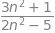

lim = 3/2


lim = 0


lim = oo


In [11]:
examples = [
    (3*n**2 + 1) / (2*n**2 - 5),   # → 3/2
    (5*n + 2) / (n**2 + 1),         # → 0
    (n**2 + 1) / (3*n + 1),         # → ∞
]

for expr in examples:
    L = sp.limit(expr, n, sp.oo)
    print("=" * 40)
    display(expr)
    print(f"lim = {L}")


## 3. 등비수열 $a_n = a r^{n-1}$ — $|r|$ 조건

$$
\lim_{n\to\infty} a r^{n-1} =
\begin{cases}
0 & (|r|<1) \\
a & (r=1) \\
\text{발산} & (|r|>1\ \text{또는}\ r=-1)
\end{cases}
$$


In [12]:
from sympy.series.limitseq import limit_seq

a, r = sp.symbols('a r', real=True)
a_n_geo = a * r**(n - 1)

cases = [
    ("|r|<1",  {a: 3, r: sp.Rational(1, 2)}),
    ("r=1",    {a: 3, r: 1}),
    ("r=-1",   {a: 3, r: -1}),
    ("|r|>1",  {a: 3, r: 2}),
    ("-1<r<0", {a: 3, r: sp.Rational(-1, 2)}),
]

for label, vals in cases:
    expr = a_n_geo.subs(vals)
    # (-1)^n 같은 진동은 sp.limit 이 NotImplementedError → limit_seq 사용
    try:
        L = sp.limit(expr, n, sp.oo)
    except NotImplementedError:
        L = limit_seq(expr, n)

    print("=" * 40)
    print(f"케이스: {label}, a={vals[a]}, r={vals[r]}")
    display(expr)
    print(f"lim(n→∞) = {L}")
    # AccumBounds(-3,3) 등은 "진동(수렴 X)" 로 읽으면 됨
    if isinstance(L, sp.AccumBounds):
        print("  → 진동 (유한 구간에 머무르지만 한 값으로 수렴하지 않음)")


케이스: |r|<1, a=3, r=1/2


lim(n→∞) = 0
케이스: r=1, a=3, r=1


lim(n→∞) = 3
케이스: r=-1, a=3, r=-1


lim(n→∞) = AccumBounds(-3, 3)
  → 진동 (유한 구간에 머무르지만 한 값으로 수렴하지 않음)
케이스: |r|>1, a=3, r=2


lim(n→∞) = oo
케이스: -1<r<0, a=3, r=-1/2


lim(n→∞) = 0


**LN**: 등비수열 수렴 $\Leftrightarrow$ $|r|<1$ (또는 $r=1$이면 상수열).

$r=-1$ 이면 $a, -a, a, -a, \ldots$ 진동 → **수렴하지 않음**.

**LN**: <br>
=> $r<0$ 인 등비·$(-1)^n$ 은 `sp.limit` 이 `NotImplementedError` 를 낼 수 있다.  
=> 이때는 `limit_seq` 를 쓰거나, `AccumBounds` / `nan` 을 **진동**으로 해석한다.


## 4. `limit_seq` — 수열 전용 극한


In [13]:
from sympy.series.limitseq import limit_seq

seqs = [
    (2*n + 1)/(n + 3),
    sp.Rational(1, 2)**(n - 1),
    (-sp.Rational(1, 3))**(n - 1),
    n / sp.factorial(n),
]

for expr in seqs:
    L = limit_seq(expr, n)
    print("=" * 40)
    display(expr)
    print(f"limit_seq = {L}")


limit_seq = 2


limit_seq = 0


limit_seq = 0


limit_seq = 0


**limit_seq(expr, n)**: <br>
=> 수열 극한 전용. `sp.limit` 과 유사하나 이산 $n$ 에 맞춘 경로


## 5. Example: 수렴 판정 요약


In [14]:
from sympy.series.limitseq import limit_seq

tests = [
    ("(n+1)/(2n-1)", (n+1)/(2*n-1)),
    ("(1/2)^n", (sp.Rational(1, 2))**n),
    ("2^n", 2**n),
    ("(-1)^n / n", (-1)**n / n),
    ("(-1)^n", (-1)**n),
]

for name, expr in tests:
    try:
        L = sp.limit(expr, n, sp.oo)
    except NotImplementedError:
        L = limit_seq(expr, n)

    if isinstance(L, sp.AccumBounds) or L is sp.nan:
        status = "진동 (수렴 X)"
    elif L in (sp.oo, -sp.oo):
        status = "발산(∞)"
    elif getattr(L, "is_finite", None):
        status = "수렴"
    else:
        status = "판정 주의"

    print("=" * 40)
    print(name)
    display(expr)
    print(f"lim = {L}  →  {status}")


(n+1)/(2n-1)


lim = 1/2  →  수렴
(1/2)^n


lim = 0  →  수렴
2^n


lim = oo  →  발산(∞)
(-1)^n / n


lim = 0  →  수렴
(-1)^n


lim = nan  →  진동 (수렴 X)
